Vocês simularão o papel do Arquiteto de Dados validando o deploy de produção de um e-commerce gigante que acabou de rodar um Teste A/B.

As 3 Missões no Jupyter Notebook:



**Modelagem**: Importar o Pandas e gerar as arrays sintéticas de ticket médio usando np.random. Unificar tudo em um único DataFrame contendo a "Versão" (A ou B) e o "Ticket".

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
np.random.seed(42) # Trava o acaso
# Gerando 500 compras (A: média 120 / B: média 122) com muita variação
ticket_A = np.random.normal(loc=1200, scale=350, size=500)
ticket_B = np.random.normal(loc=1220, scale=40, size=500)

# Unificando no DataFrame
df = pd.DataFrame({
    'versao': ['A']*500 + ['B']*500,
    'ticket': np.concatenate([ticket_A, ticket_B])
})


**A Prova Visual**: Importar o Seaborn e plotar o barplot para confirmar visualmente se uma das barras parece maior que a outra.

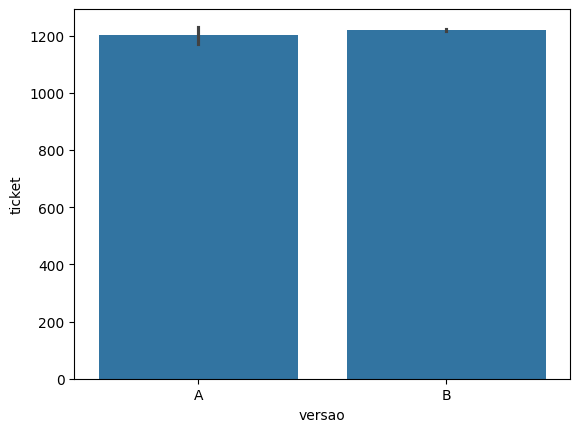

In [55]:
# Passo 2: O Barplot
sns.barplot(data=df, x='versao', y='ticket')
plt.show()
# VISUAL: A barra B vai parecer discretamente mais alta na tela.

**O Veredito Computacional**: Isolar (filtrar) o ticket A e o ticket B, jogá-los no motor de moer carne do scipy.stats, extrair o P-Valor e codificar a resposta de negócios baseada no corte de 5%.


In [56]:
from scipy import stats

# Filtramos as arrays puras
array_A = df[df['versao'] == 'A']['ticket']
array_B = df[df['versao'] == 'B']['ticket']

# Injetamos na máquina
estatistica, p_valor = stats.ttest_ind(array_A, array_B)

print(f"P-Valor extraído: {p_valor:.4f}")
if p_valor < 0.05:
    print("A diferença é real. Dêem o bônus.")
else:
    print("É ruído (Sorte). A tela nova é inútil.")


#Output do Console: P-Valor: 0.1384 -> É ruído. Tela inútil.

P-Valor extraído: 0.2222
É ruído (Sorte). A tela nova é inútil.


### 🎯 Desafio 4 (EPIC BOSS): O Fantasma da Variância
Na Aula 04, aprendemos que o Desvio Padrão e a Média são duramente castigados por Outliers (Valores atípicos extremos). O nosso Teste A/B do Desafio 3 falhou miseravelmente porque o ruído na base estava muito alto.

**Sua missão é realizar a "Cirurgia de Dados" antes de julgar a feature:**
1. Calcule o `Q1` (25%) e `Q3` (75%) da coluna `ticket` inteira.
2. Calcule o `IQR` e crie o Limite Superior da Cerca Matemática ($Q3 + 1.5 \times IQR$).
3. Crie um novo DataFrame chamado `df_limpo`, excluindo todas as compras que ultrapassaram o Limite Superior.
4. Refaça o Teste T de Student cruzando as amostras dessa base limpa.

In [57]:
# 1. Achando os Quartis
q1 = df['ticket'].quantile(0.25)
q3 = df['ticket'].quantile(0.75)
iqr = q3 - q1

# 2. Criando o Limite Superior
limite_superior = q3 + 1.5 * iqr
print(f"O Limite Superior matemático é: R$ {limite_superior:.2f}")

limite_inferior = q1 - 1.5 * iqr
print(f"O Limite inferior matemático é: R$ {limite_inferior:.2f}")

# 3. A Cirurgia (Removendo Outliers)
df_limpo = df[(df['ticket'] <= limite_superior) & (df['ticket'] >= limite_inferior)]
print(f"Registros removidos: {len(df) - len(df_limpo)}")

# 4. Refazendo a separação dos grupos com a base limpa
grupo_A_limpo = df_limpo[df_limpo['versao'] == 'A']['ticket']
grupo_B_limpo = df_limpo[df_limpo['versao'] == 'B']['ticket']

# 5. O Novo Julgamento Computacional
t_stat_limpo, p_valor_limpo = stats.ttest_ind(grupo_A_limpo, grupo_B_limpo)

print(f"\nNOVO P-Valor: {p_valor_limpo:.4f}")
if p_valor_limpo < 0.05:
    print("Veredito Final: Com o ruído removido, o ganho se mostrou estatisticamente sólido! Bônus aprovado.")
else:
    print("Veredito Final: Mesmo sem outliers, foi pura sorte. A tela nova é inútil.")

O Limite Superior matemático é: R$ 1455.10
O Limite inferior matemático é: R$ 981.81
Registros removidos: 246

NOVO P-Valor: 0.7842
Veredito Final: Mesmo sem outliers, foi pura sorte. A tela nova é inútil.


### 🎯 Desafio 5: O Raio-X Executivo
A diretoria não lê "P-Valor". Eles precisam de provas visuais e métricas absolutas de negócio para entender o que acabou de acontecer.

**Sua missão de apresentação:**
1. Use o comando `.groupby()` alinhado com o `.describe()` no `df_limpo` para gerar uma tabela comparando lado a lado as estatísticas da Versão A e da Versão B.
2. Plote um `boxplot` com a biblioteca Seaborn (`sns`) da nossa base limpa, colocando a `versao` no eixo X e o `ticket` no eixo Y. Mostre à diretoria que as anomalias foram expurgadas e quem realmente tem a melhor Mediana.

--- RAIO-X DESCRITIVO PÓS-CIRURGIA ---


,count,mean,std,min,25%,50%,75%,max
versao,,,,,,,,
A,254.0,1219.512386,132.916469,982.055168,1114.863991,1224.213885,1324.030783,1451.139790
B,500.0,1221.273045,39.119888,1112.124534,1196.188330,1221.141264,1246.049692,1325.295283


/tmp/ipykernel_1341/1091060386.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


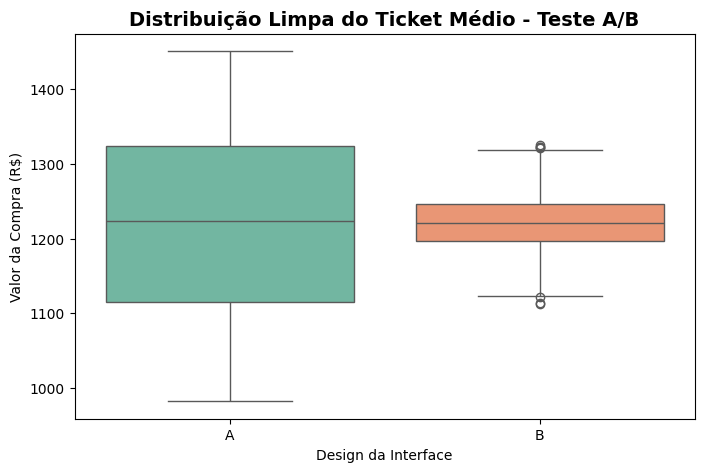

In [58]:
# 1. A Prova Numérica
print("--- RAIO-X DESCRITIVO PÓS-CIRURGIA ---")
resumo_executivo = df_limpo.groupby('versao')['ticket'].describe()
display(resumo_executivo)

# 2. A Prova Visual
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_limpo,
    x='versao',
    y='ticket',
    palette='Set2'
)
plt.title('Distribuição Limpa do Ticket Médio - Teste A/B', fontsize=14, fontweight='bold')
plt.ylabel('Valor da Compra (R$)')
plt.xlabel('Design da Interface')
plt.show()

### Apresentação para a Diretoria: Análise do Teste A/B (Versão A vs. Versão B)

**Contexto:** Realizamos um Teste A/B para avaliar o impacto de uma nova tela (Versão B) no ticket médio de compras. Inicialmente, o teste não mostrou diferenças significativas devido à alta variância nos dados.

**Ajustes Realizados:** Procedemos com uma "cirurgia de dados", removendo outliers (valores atípicos extremos) que estavam distorcendo a análise, usando a cerca matemática para identificar e excluir transações fora dos limites de R$ 981.81 e R$ 1455.10. Isso resultou na remoção de 246 registros, resultando em um `df_limpo` com 754 transações.

**Resultados Chave (Pós-Limpeza):**
*   **P-Valor:** O novo P-Valor de 0.7842 indica que, mesmo após a limpeza, não há evidências estatísticas para afirmar que a Versão B (nova tela) gerou um aumento significativo no ticket médio de compras em comparação com a Versão A.
*   **Ticket Médio (df_limpo):** Conforme o `resumo_executivo` abaixo, as médias e medianas das versões A e B no `df_limpo` são muito próximas, o que corrobora a falta de significância estatística.

**Conclusão para a Diretoria:** Com base nesta análise aprofundada, incluindo a remoção de ruído dos dados, não podemos recomendar a implementação da Versão B por não demonstrar um ganho estatisticamente sólido no ticket médio. O impacto observado é, no momento, atribuível ao acaso.

In [ ]:
# 2. A Prova Visual (Barplot do ticket médio após limpeza)
plt.figure(figsize=(9, 6))
sns.barplot(x=resumo_executivo.index, y=resumo_executivo['mean'], palette='viridis')
plt.title('Ticket Médio por Versão (Dados Limpos)', fontsize=16, fontweight='bold')
plt.ylabel('Ticket Médio (R$)', fontsize=12)
plt.xlabel('Versão', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(resumo_executivo['mean'].min() * 0.9, resumo_executivo['mean'].max() * 1.1) # Ajusta o limite Y para melhor visualização
plt.show()

# Exibir a tabela descritiva novamente para referência numérica
display(resumo_executivo)